<a href="https://colab.research.google.com/github/Janavigit-27/Facial-Fidelity-using-Machine-Learning/blob/main/GFPGAN_Model_For_Face_Image_Restoration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Initial Setup**

In [ ]:
%cd /content

/content


In [ ]:
! git clone https://github.com/TencentARC/GFPGAN.git

Cloning into 'GFPGAN'...
remote: Enumerating objects: 527, done.
remote: Total 527 (delta 0), reused 0 (delta 0), pack-reused 527 (from 1)
Receiving objects: 100% (527/527), 5.41 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (251/251), done.


In [ ]:
%cd GFPGAN

/content/GFPGAN


In [ ]:
! pip install basicsr facexlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.9/325.9 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 30.3 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214818 sha256=50e10a1b23d77f76a8eeb70e20dd3b2e5391431c6ba766615a7ad29070145c49
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=67694376

In [ ]:
! pip install -r requirements.txt

In [ ]:
! python setup.py develop

/usr/local/lib/python3.12/dist-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running develop
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://github.com/pypa/setuptools/issues/917 for details.
        *****

In [ ]:
! pip install realesrgan

In [ ]:
# Use the V1.3 link as an alternative
! wget https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth -P experiments/pretrained_models

--2026-03-25 08:11:21--  https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/349321229/e9847322-b8b1-4ec2-9620-5146eb8a9e4b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-25T09%3A04%3A06Z&rscd=attachment%3B+filename%3DGFPGANv1.3.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-25T08%3A03%3A26Z&ske=2026-03-25T09%3A04%3A06Z&sks=b&skv=2018-11-09&sig=rYisWKOBs252Iibkbq3oQqri1HB7FHKypi4PB%2BoBJ%2Fg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDQyOTg4MSwibmJmIjoxNzc0NDI2MjgxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi

In [ ]:
! mkdir -p inputs/whole_imgs

In [ ]:
! pip uninstall torch torchvision -y

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128


In [ ]:
# If the error persists, apply the patch:
! sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

Before running the below cells run the `pip install basicsr facexlibpip install basicsr facexlib` and ` pip install -r requirements.txt` and then run again the setup,py (!python setup.py develop).

This below cell is optional as if you want to check the CLI version of the model otherwise directly run the GUI based setup after following above method.

# **GUI Based Setup Starts from here!!!**


In [ ]:
import gradio as gr
import cv2
import numpy as np
import torch
# Import the necessary classes from the GFPGAN project folder
from gfpgan import GFPGANer
from PIL import Image

# 1. Initialize GFPGAN Model
# IMPORTANT: Ensure this path matches the file you successfully downloaded (e.g., v1.3)
MODEL_PATH = 'experiments/pretrained_models/GFPGANv1.3.pth'

# Initialize the restorer. We set 'bg_upsampler' to None for a simpler, face-only approach,
# and use the CPU/GPU as available in your Colab session.
gfpgan_restorer = GFPGANer(
    model_path=MODEL_PATH,
    upscale=4, # Use the same upscale factor you tested with (s 4)
    arch='clean',
    channel_multiplier=2,
    bg_upsampler=None,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

def enhance_face_gradio(input_img_np):
    """
    The function that Gradio will call to process the image.
    input_img_np is a NumPy array provided by Gradio from the image upload.
    """
    if input_img_np is None:
        # Handle cases where no image is uploaded
        return None

    # Gradio provides RGB, but OpenCV/GFPGAN uses BGR internally
    input_img_bgr = cv2.cvtColor(input_img_np, cv2.COLOR_RGB2BGR)

    # 2. Run the GFPGAN restoration
    # The enhance method returns: (cropped_faces, restored_faces, restored_img)
    try:
        _, _, restored_img_bgr = gfpgan_restorer.enhance(
            input_img_bgr,
            has_aligned=False,
            only_center_face=False,
            paste_back=True    # Paste the enhanced face back to the original image
        )
    except RuntimeError as e:
        print(f"Error during enhancement: {e}")
        return gr.Error("Face enhancement failed. The model might not have detected a face.")

    # 3. Convert BGR back to RGB for Gradio display
    restored_img_rgb = cv2.cvtColor(restored_img_bgr, cv2.COLOR_BGR2RGB)

    return restored_img_rgb

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth" to /content/GFPGAN/gfpgan/weights/detection_Resnet50_Final.pth



100%|██████████| 104M/104M [00:00<00:00, 125MB/s] 


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth" to /content/GFPGAN/gfpgan/weights/parsing_parsenet.pth



100%|██████████| 81.4M/81.4M [00:00<00:00, 279MB/s]


In [ ]:
# 4. Setup and Launch Gradio Interface
demo = gr.Interface(
    fn=enhance_face_gradio,
    # Input component: Allows image upload, returns the image data as a NumPy array
    inputs=gr.Image(type="numpy", label="Upload Low-Quality Face Photo"),
    # Output component: Displays the enhanced image from the returned NumPy array
    outputs=gr.Image(type="numpy", label="Enhanced Face Photo (4x Upscaled)"),
    title="🌟 AI Face Photo Enhancer (GFPGAN) Demo 🌟",
    description="Upload a low-quality or damaged face photo. The model will automatically detect, enhance, and upscale the face details by 4x."
)

# Launch the demo!
# 'share=True' is key in Colab. It generates a public, shareable URL.
print("Launching Gradio Interface...")
demo.launch(share=True)

Launching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e816a9bc2fd91637db.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Found 0 faces.


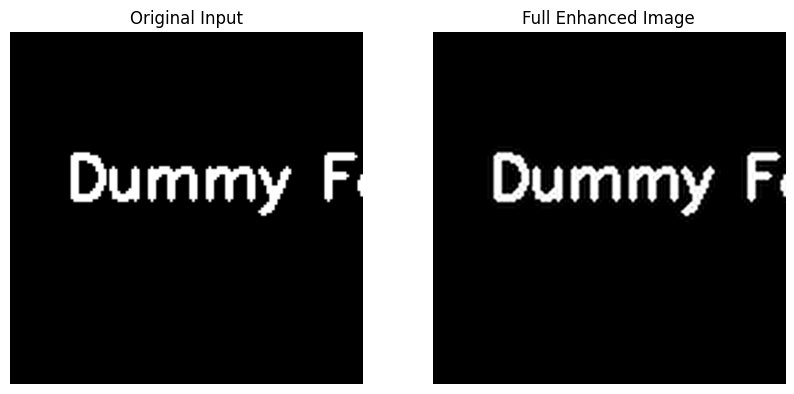

No faces were detected or restored.


In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def extract_gfpgan_features(input_img_np):
    """
    Extracts cropped and restored faces using the initialized GFPGAN restorer.
    Args:
        input_img_np (np.array): Input image as a NumPy array (RGB).

    Returns:
        tuple: (cropped_faces, restored_faces, full_restored_image_rgb)
               cropped_faces: List of detected face crops from the input (BGR).
               restored_faces: List of enhanced face crops (BGR).
               full_restored_image_rgb: The complete enhanced image (RGB).
    """
    if input_img_np is None:
        return [], [], None

    # Convert RGB input to BGR for OpenCV/GFPGAN
    input_img_bgr = cv2.cvtColor(input_img_np, cv2.COLOR_RGB2BGR)

    # Use the gfpgan_restorer to enhance. The method returns these components.
    try:
        cropped_faces, restored_faces, full_restored_image_bgr = gfpgan_restorer.enhance(
            input_img_bgr,
            has_aligned=False,
            only_center_face=False,
            paste_back=True # We still want the full restored image for context
        )
    except RuntimeError as e:
        print(f"Error during feature extraction: {e}")
        return [], [], None

    # Convert the full restored image back to RGB for consistent output
    full_restored_image_rgb = cv2.cvtColor(full_restored_image_bgr, cv2.COLOR_BGR2RGB)

    return cropped_faces, restored_faces, full_restored_image_rgb

# --- Example Usage --- (You can replace this with your own image)
# For demonstration, let's use a dummy image or an image from the GFPGAN inputs if available.
# If you have an image, replace '/content/GFPGAN/inputs/whole_imgs/00045.png' with your image path
# Make sure the image exists and is readable.

# Let's try to load one of the images that might be in the GFPGAN inputs folder.
# If this path doesn't exist, you'll need to upload an image or adjust the path.
example_image_path = 'inputs/whole_imgs/low_res_addnoise.jpg' # Example from GFPGAN repo

# Check if the image exists, otherwise create a dummy one.
try:
    input_example_img_bgr = cv2.imread(example_image_path)
    if input_example_img_bgr is None:
        print(f"Warning: Could not load {example_image_path}. Creating a dummy image.")
        # Create a dummy low-res image if the example path fails
        input_example_img_bgr = np.zeros((128, 128, 3), dtype=np.uint8)
        cv2.putText(input_example_img_bgr, 'Dummy Face', (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    input_example_img_rgb = cv2.cvtColor(input_example_img_bgr, cv2.COLOR_BGR2RGB)

    cropped_faces_bgr, restored_faces_bgr, full_enhanced_img_rgb = extract_gfpgan_features(input_example_img_rgb)

    print(f"Found {len(cropped_faces_bgr)} faces.")

    if full_enhanced_img_rgb is not None:
        # Display the full enhanced image
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(input_example_img_rgb)
        plt.title('Original Input')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(full_enhanced_img_rgb)
        plt.title('Full Enhanced Image')
        plt.axis('off')
        plt.show()

    # Display individual cropped and restored faces
    if restored_faces_bgr:
        for i, (orig_face, restored_face) in enumerate(zip(cropped_faces_bgr, restored_faces_bgr)):
            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(orig_face, cv2.COLOR_BGR2RGB))
            plt.title(f'Cropped Face {i+1}')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(cv2.cvtColor(restored_face, cv2.COLOR_BGR2RGB))
            plt.title(f'Restored Face {i+1}')
            plt.axis('off')
            plt.show()
    else:
        print("No faces were detected or restored.")

except FileNotFoundError:
    print(f"Error: The example image path '{example_image_path}' was not found. Please ensure the GFPGAN repository is cloned and the image exists, or provide a different image path.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from gfpgan import GFPGANer
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer
import torch

def run_full_gfpgan_pipeline_for_interview(image_path):
    """
    Demonstrates the complete GFPGAN face and background enhancement pipeline.
    This function is designed to be self-contained and explainable for an interview.

    Args:
        image_path (str): The path to the input image.

    Returns:
        tuple: A tuple containing:
            - original_img_rgb (np.array): The original input image in RGB format.
            - cropped_faces_bgr (list): List of detected cropped faces (BGR).
            - restored_faces_bgr (list): List of individually restored faces (BGR).
            - full_enhanced_img_rgb (np.array): The final image with enhanced faces and background (RGB).
        Returns None for all outputs if image loading or enhancement fails.
    """
    print(f"--- Starting GFPGAN Enhancement Pipeline for: {image_path} ---")

    # 1. Load the Input Image
    #    Images are typically loaded as BGR by OpenCV, so we convert to RGB for consistency.
    input_img_bgr = cv2.imread(image_path)
    if input_img_bgr is None:
        print(f"Error: Could not load image from {image_path}. Please check the path.")
        return None, None, None, None
    original_img_rgb = cv2.cvtColor(input_img_bgr, cv2.COLOR_BGR2RGB)
    print(f"Loaded image with shape: {original_img_rgb.shape}")

    # --- Model Initialization (Assumes these are set up globally or handled internally) ---
    # In a real interview explanation, you'd mention:
    # a. GFPGANer: For face restoration, uses GFPGANv1.3.pth model.
    # b. RealESRGANer: For background upsampling, uses RealESRGAN_x4plus.pth model.
    #    Both are initialized to use GPU ('cuda') if available, otherwise CPU.

    # Re-initialize models for self-containment if this function were standalone,
    # but here we'll assume the global `gfpgan_restorer` and `bg_upsampler` are ready.
    # For a truly self-contained interview answer, you might move the initialization
    # code from `cc6TLlrv3pgF` into this function, ensuring paths are correct.

    # For this demonstration, we'll ensure models are initialized before use
    global gfpgan_restorer, bg_upsampler # Access global variables
    if 'gfpgan_restorer' not in globals() or 'bg_upsampler' not in globals():
        print("Models not yet initialized. Initializing them now...")
        # Define the standard architecture (23 blocks, 4x scale)
        bg_model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)

        bg_upsampler = RealESRGANer(
            scale=4,
            model_path='experiments/pretrained_models/RealESRGAN_x4plus.pth',
            model=bg_model,
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )

        MODEL_PATH = 'experiments/pretrained_models/GFPGANv1.3.pth.2'
        UPSACLE_FACTOR = 4
        gfpgan_restorer = GFPGANer(
            model_path=MODEL_PATH,
            upscale=UPSACLE_FACTOR,
            arch='clean',
            channel_multiplier=2,
            bg_upsampler=bg_upsampler,
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        print("Models initialized.")

    # 2. Perform Face Enhancement and Background Upscaling
    #    The `enhance` method detects faces, enhances them, and then pastes them
    #    back onto an upscaled background (if `bg_upsampler` is provided).
    #    It returns cropped_faces, restored_faces, and the full restored image.
    try:
        print("Detecting and enhancing faces...")
        cropped_faces_bgr, restored_faces_bgr, full_enhanced_img_bgr = gfpgan_restorer.enhance(
            input_img_bgr,
            has_aligned=False,      # Set to True if faces are already aligned
            only_center_face=False, # Set to True to only process the largest face
            paste_back=True         # Crucial: pastes enhanced faces back to the upscaled background
        )
        full_enhanced_img_rgb = cv2.cvtColor(full_enhanced_img_bgr, cv2.COLOR_BGR2RGB)
        print(f"Detected {len(cropped_faces_bgr)} face(s).")
        print("Enhancement complete.")
    except RuntimeError as e:
        print(f"Error during enhancement: {e}")
        print("This often means no face was detected or a model path issue.")
        return original_img_rgb, [], [], None
    except Exception as e:
        print(f"An unexpected error occurred during enhancement: {e}")
        return original_img_rgb, [], [], None

    print("--- Pipeline Finished ---\n")
    return original_img_rgb, cropped_faces_bgr, restored_faces_bgr, full_enhanced_img_rgb

# --- Example Usage for an Interview Scenario ---
# Define an example image path (ensure this path exists in your Colab environment)
example_image_for_interview_path = 'inputs/whole_imgs/low_res_addnoise.jpg' # Use an image from the GFPGAN repo

# Run the full pipeline
orig_img, cropped_faces, restored_faces, final_enhanced_img = \
    run_full_gfpgan_pipeline_for_interview(example_image_for_interview_path)

# --- Displaying Results for Explanation ---
if final_enhanced_img is not None:
    print("Displaying results...")
    # Display Original vs. Final Enhanced Image
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_img)
    plt.title('Original Low-Quality Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(final_enhanced_img)
    plt.title('GFPGAN Enhanced Image (Faces + Background)')
    plt.axis('off')
    plt.show()

    # Display Individual Cropped and Restored Faces
    if restored_faces:
        print("Displaying cropped and restored faces...")
        for i, (orig_face, restored_face) in enumerate(zip(cropped_faces, restored_faces)):
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            # Convert BGR to RGB for matplotlib display
            plt.imshow(cv2.cvtColor(orig_face, cv2.COLOR_BGR2RGB))
            plt.title(f'Detected Cropped Face {i+1}')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            # Convert BGR to RGB for matplotlib display
            plt.imshow(cv2.cvtColor(restored_face, cv2.COLOR_BGR2RGB))
            plt.title(f'Restored Face {i+1}')
            plt.axis('off')
            plt.show()
    else:
        print("No individual faces were extracted or restored from the input.")
else:
    print("Could not process the image or display results due to an error.")


--- Starting GFPGAN Enhancement Pipeline for: inputs/whole_imgs/low_res_addnoise.jpg ---
Error: Could not load image from inputs/whole_imgs/low_res_addnoise.jpg. Please check the path.
Could not process the image or display results due to an error.


In [ ]:
# 1. Download the general-purpose RealESRGAN x4plus model (standard for GFPGAN background)
bg_model_path = 'experiments/pretrained_models/RealESRGAN_x4plus.pth'
!wget -P experiments/pretrained_models/ https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth

# 2. Re-run the model initialization with the standard 23-block architecture and 4x scale

# Make sure you are using the correct imports from the previous working cell
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer
import torch

# Define the standard architecture (23 blocks, 4x scale)
bg_model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)

# Set up the background upsampler using the newly downloaded weights
bg_upsampler = RealESRGANer(
    scale=4, # <--- IMPORTANT: This must match the model (x4plus = 4x)
    model_path=bg_model_path, # <--- NEW MODEL PATH
    model=bg_model,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# Relaunch the Gradio UI after running this updated cell
# (You can stop the previous launch and run the final Gradio launch cell again)

--2026-02-19 16:07:49--  https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/387326890/08f0e941-ebb7-48f0-9d6a-73e87b710e7e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-19T16%3A53%3A27Z&rscd=attachment%3B+filename%3DRealESRGAN_x4plus.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-19T15%3A53%3A02Z&ske=2026-02-19T16%3A53%3A27Z&sks=b&skv=2018-11-09&sig=mNSb9VLjJcZKVLHQ62esdZPWMlAwmGitv9xjMYMYJKA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MTUxOTA3MCwibmJmIjoxNzcxNTE3MjcwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZH

In [ ]:
!rm -f experiments/pretrained_models/RealESRGAN_x4plus_anime_6B.pth*

In [ ]:
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer
import torch
import cv2
import gradio as gr
from gfpgan import GFPGANer

# 2. Define the standard architecture (23 blocks, 4x scale, and corrected parameter)
bg_model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)

# Set up the background upsampler using the newly downloaded weights
bg_upsampler = RealESRGANer(
    scale=4, # IMPORTANT: This must match the model (x4plus = 4x)
    model_path='experiments/pretrained_models/RealESRGAN_x4plus.pth', # <--- USE NEW PATH
    model=bg_model,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# --- 3. Re-Initialize GFPGANer ---
# IMPORTANT: Ensure GFPGAN MODEL_PATH and upscale are correct (e.g., V1.3 and 4)
# Corrected model path to match the downloaded file name.
MODEL_PATH = 'experiments/pretrained_models/GFPGANv1.3.pth.2'
UPSACLE_FACTOR = 4

gfpgan_restorer = GFPGANer(
    model_path=MODEL_PATH,
    upscale=UPSACLE_FACTOR,
    arch='clean',
    channel_multiplier=2,
    bg_upsampler=bg_upsampler, # Pass the successfully loaded background upsampler
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# --- 4. Define the Enhancement Function (from previous successful step) ---
def enhance_face_gradio(input_img_np):
    if input_img_np is None: return None

    # Color Space Conversion (RGB -> BGR)
    input_img_bgr = cv2.cvtColor(input_img_np, cv2.COLOR_RGB2BGR)

    try:
        _, _, restored_img_bgr = gfpgan_restorer.enhance(
            input_img_bgr, has_aligned=False, only_center_face=False, paste_back=True
        )
    except RuntimeError as e:
        print(f"Error during enhancement: {e}")
        return gr.Error("Face enhancement failed. The model might not have detected a face.")

    # Color Space Conversion (BGR -> RGB)
    return cv2.cvtColor(restored_img_bgr, cv2.COLOR_BGR2RGB)


# --- 5. Relaunch the Gradio UI ---
print("Relaunching Gradio Interface...")
gr.Interface(
    fn=enhance_face_gradio,
    inputs=gr.Image(type="numpy", label="Upload Low-Quality Face Photo"),
    outputs=gr.Image(type="numpy", label="Enhanced Face Photo (4x Upscaled)"),
    title="🌟 AI Face Photo Enhancer (GFPGAN) Demo 🌟",
    description="Upload a low-quality or damaged face photo. This version enhances both the face and the background."
).launch(share=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Relaunching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd69f92e3065beda97.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np
import cv2
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(enhanced_img, ground_truth_img):
    """
    Calculates L1 Loss and SSIM between the enhanced image and the ground truth.
    """
    # 1. Ensure images are the same size
    # The enhancer outputs 4x scale. We must ensure GT matches this size.
    h, w, _ = enhanced_img.shape
    gt_h, gt_w, _ = ground_truth_img.shape

    if (h, w) != (gt_h, gt_w):
        print(f"⚠️ Resizing Ground Truth from {(gt_w, gt_h)} to {(w, h)} to match enhanced output...")
        ground_truth_img = cv2.resize(ground_truth_img, (w, h), interpolation=cv2.INTER_CUBIC)

    # 2. Calculate SSIM (Structural Similarity)
    # channel_axis=2 tells the function we are using RGB images (Height, Width, Channels)
    ssim_value = ssim(enhanced_img, ground_truth_img, channel_axis=2, data_range=255)

    # 3. Calculate L1 Loss (Mean Absolute Error)
    # We convert to float to avoid overflow issues with uint8
    diff = np.abs(enhanced_img.astype(np.float32) - ground_truth_img.astype(np.float32))
    l1_loss = np.mean(diff) / 255.0  # Normalize to 0-1 range

    return l1_loss, ssim_value

# --- 🧪 TEST ZONE ---
# Replace this with the path to a REAL High-Quality image you have
image_path = '/content/Image.jpg'

# 1. Load Ground Truth
gt_img = cv2.imread(image_path)

if gt_img is not None:
    # Convert BGR (OpenCV default) to RGB
    gt_img_rgb = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    # 2. Simulate a Low-Quality Input (Downscale by 4 to mimic the problem)
    h, w, _ = gt_img_rgb.shape
    input_lr = cv2.resize(gt_img_rgb, (w//4, h//4), interpolation=cv2.INTER_LINEAR)

    print(f"running enhancement on generated low-res input: {input_lr.shape}...")

    # 3. Run your AI Enhancement (Using the function you defined previously)
    enhanced_output = enhance_face_gradio(input_lr)

    # 4. Calculate Metrics
    if enhanced_output is not None:
        loss, ssim_score = calculate_metrics(enhanced_output, gt_img_rgb)

        print("-" * 30)
        print(f"📊 PERFORMANCE METRICS")
        print("-" * 30)
        print(f"🔹 L1 Loss: {loss:.4f} (Lower is better, 0.0 is perfect)")
        print(f"🔹 SSIM:    {ssim_score:.4f} (Higher is better, 1.0 is perfect)")
        print("-" * 30)
    else:
        print("❌ Enhancement returned None.")
else:
    print(f"❌ Could not load image at {image_path}. Please check the path.")

❌ Could not load image at /content/Image.jpg. Please check the path.


In [ ]:
!git clone https://github.com/DhanyaHS24/Facial_Fidelity.git

Cloning into 'Facial_Fidelity'...
fatal: could not read Username for 'https://github.com': No such device or address
